# Music Genre Classification - Version 2 (Ensemble)

This notebook implements an advanced solution for the Music Genre Classification task, inspired by the "House Price V2" pattern.

## Key Improvements over V1:
1. **Better Preprocessing**: Robust imputation and scaling.
2. **Multi-Model Training**: Training RandomForest, LightGBM, XGBoost, and CatBoost using `src` pipelines.
3. **Cross-Validation**: 5-Fold Stratified CV for all models to ensure stability.
4. **Ensemble**: Weighted soft-voting ensemble of the best models to maximize F1 Macro score.
5. **Artifacts**: Saving all models, metrics, and OOF predictions for analysis.

## 1. Setup & Imports

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append(os.path.abspath("src"))

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.stats import mode

# Import pipelines
from pipeline.RFPipline import RFPipeline
from pipeline.LightGBMPipline import LightGBMPipeline
from pipeline.XGBoostPipeline import XGBoostPipeline
from pipeline.CatBoostPipeline import CatBoostPipeline

# Configuration
RANDOM_STATE = 42
N_SPLITS = 5
DATA_DIR = "data"
EXP_DIR = "experiments/Music_V2"

os.makedirs(EXP_DIR, exist_ok=True)
os.makedirs(os.path.join(EXP_DIR, "models"), exist_ok=True)

np.random.seed(RANDOM_STATE)

## 2. Load Data

In [2]:
train_path = os.path.join(DATA_DIR, "train.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

display(train_df.head())

# Check Class distribution
target_col = "Class"
print("\nClass Distribution:")
print(train_df[target_col].value_counts(normalize=True))

Train shape: (14396, 18)
Test shape: (3600, 17)


,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,1,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,NaN,0.106,0.235,152.429,204947.0,4,9
1,2,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.0468,0.104,0.380,132.921,191956.0,4,6
2,3,Royal & the Serpent,phuck u,NaN,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.6350,0.284,0.635,159.953,161037.0,4,10
3,4,Detroit Blues Band,Missing You,12.0,0.515,0.308,NaN,-14.711,1,0.0312,0.907000,0.0213,0.300,0.501,172.472,298093.0,3,2
4,5,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,NaN,0.211,0.619,88.311,254145.0,4,5



Class Distribution:
Class
10    0.275007
6     0.143720
9     0.140247
8     0.103015
5     0.080370
1     0.076271
2     0.070714
0     0.034732
7     0.032023
3     0.022367
4     0.021534
Name: proportion, dtype: float64


## 3. Feature Selection & Preprocessing
We focus on numeric features as in the baseline, but apply robust scaling and imputation.

In [3]:
NUM_FEATURES = [
    "Popularity",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_in min/ms",
    "time_signature",
]

# Prepare X and y
X = train_df[NUM_FEATURES].copy()
y = train_df[target_col].copy()
X_test = test_df[NUM_FEATURES].copy()

# --- Preprocessing ---
# 1. Impute Missing Values (Median)
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# 2. Scale Features (StandardScaler)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test.columns)

# 3. Label Encoding for Target (if needed)
# Ensure y is integer for models
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Preprocessing complete.")
print(f"Classes: {le.classes_}")

Preprocessing complete.
Classes: [ 0  1  2  3  4  5  6  7  8  9 10]


## 4. Model Training (Multi-Model CV)
We will train 4 strong models: **RandomForest, LightGBM, XGBoost, CatBoost**.
For each, we run 5-fold Stratified CV and save the best model.

Starting 5-Fold CV for ['RandomForest', 'LightGBM', 'XGBoost', 'CatBoost']...

========== Fold 0 ==========

Training RandomForest...

🚀 Start run: RandomForest_Fold0_classification_best_110747


[I 2025-11-21 11:07:47,580] A new study created in memory with name: no-name-0e26af8c-0268-4b10-bf34-aacbfb622af6


🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 11:07:50,034] Trial 0 finished with value: 0.5515383214413846 and parameters: {'n_estimators': 100, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_samples': 0.7514710865284522}. Best is trial 0 with value: 0.5515383214413846.
[I 2025-11-21 11:07:53,156] Trial 1 finished with value: 0.5499090880560797 and parameters: {'n_estimators': 500, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_samples': 0.7952974549661901}. Best is trial 0 with value: 0.5515383214413846.
[I 2025-11-21 11:07:56,719] Trial 2 finished with value: 0.49197785754086826 and parameters: {'n_estimators': 500, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_samples': 0.9085310339654369}. Best is trial 0 with value: 0.5515383214413846.
[I 2025-11-21 11:07:59,177] Trial 3 finished with value: 0.5466772580958 and parameters: {'n_estimators': 300, 'max_depth': 11, 'min_samples_spli

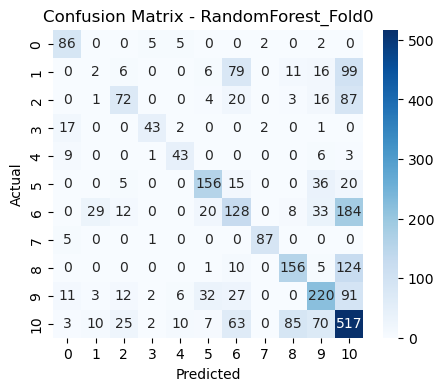

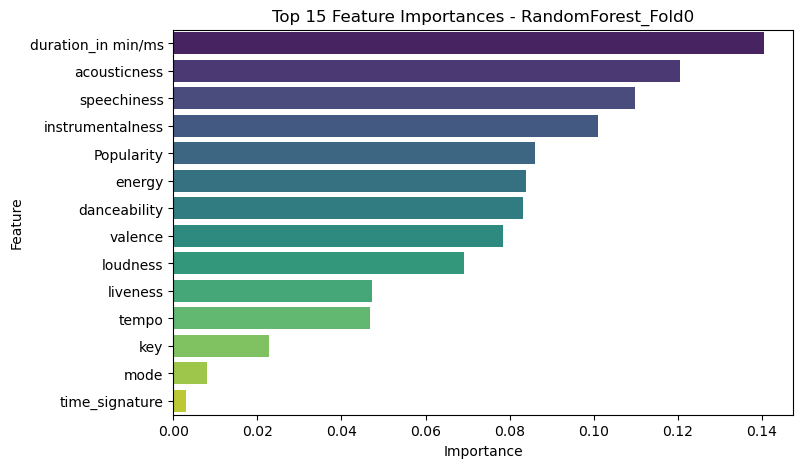

2025/11/21 11:08:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Model đã được lưu tại: experiments/models\RandomForest_Fold0_best.pkl
✅ Mô hình đã lưu local: experiments/models\RandomForest_Fold0_classification_best_110747_20251121_110856_model.pkl


2025/11/21 11:09:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[I 2025-11-21 11:09:10,380] A new study created in memory with name: no-name-73ba6088-d5f4-4232-b438-69a602883b01


✅ Dữ liệu đã lưu local: experiments/data/processed\RandomForest_Fold0_classification_best_110747_20251121_110910_data.csv
  -> RandomForest Fold 0 F1 Macro: 0.5628

Training LightGBM...

🚀 Start run: LightGBM_Fold0_classification_best_110910
🔍 Đang tìm tham số tốt nhất cho LightGBM bằng Optuna (10 lần thử)...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-11-21 11:09:38,031] Trial 0 finished with value: 0.5542246115857921 and parameters: {'n_estimators': 606, 'learning_rate': 0.024038553682293705, 'max_depth': 9, 'num_leaves': 163, 'subsample': 0.6806342379807756, 'colsample_bytree': 0.5076231335927075, 'lambda_l1': 3.50036844971991e-07, 'lambda_l2': 0.7411874652171443, 'min_child_samples': 43}. Best is trial 0 with value: 0.5542246115857921.
[I 2025-11-21 11:09:56,317] Trial 1 finished with value: 0.5592011788774657 and parameters: {'n_estimators': 1395, 'learning_rate': 0.051711000162345436, 'max_depth': 7, 'num_leaves': 40, 'subsample': 0.8672307143679314, 'colsample_bytree': 0.6884763071424049, 'lambda_l1': 1.8365140228818395, 'lambda_l2': 0.02222548020175928, 'min_child_samples': 26}. Best is trial 1 with value: 0.5592011788774657.
[I 2025-11-21 11:10:14,761] Trial 2 finished with value: 0.5553984082987523 and parameters: {'n_estimators': 515, 'learning_rate': 0.04763989366647468, 'max_depth': 9, 'num_leaves': 109, 'subsamp

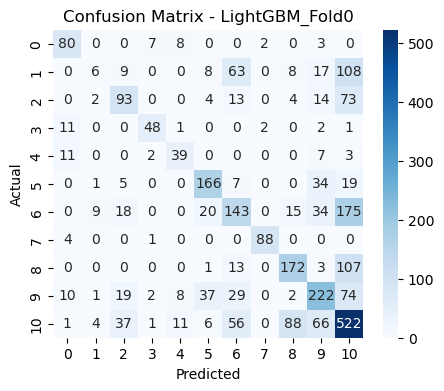

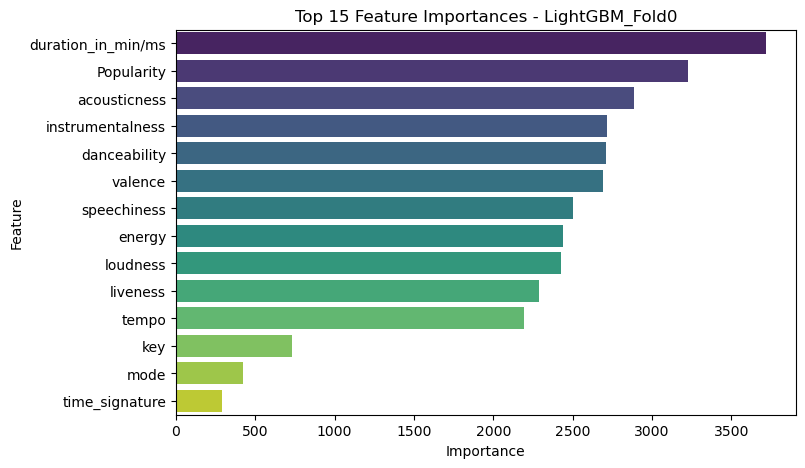

✅ Đã chạy đánh giá đầy đủ cho task: classification.


2025/11/21 11:12:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\LightGBM_Fold0_classification_best_110910_20251121_111242_model.pkl


2025/11/21 11:12:49 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\LightGBM_Fold0_classification_best_110910_20251121_111249_data.csv
[LightGBM] [Warning] lambda_l1 is set=3.441375045250056e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.441375045250056e-08
[LightGBM] [Warning] lambda_l2 is set=0.0276953915953339, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0276953915953339
  -> LightGBM Fold 0 F1 Macro: 0.5794
[LightGBM] [Warning] lambda_l1 is set=3.441375045250056e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.441375045250056e-08
[LightGBM] [Warning] lambda_l2 is set=0.0276953915953339, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0276953915953339

Training XGBoost...

🚀 Start run: XGBoost_Fold0_classification_best_111249


[I 2025-11-21 11:12:49,570] A new study created in memory with name: no-name-9f095a91-9d91-4d05-83b9-269addaf947a


🔍 Đang tìm tham số tốt nhất cho XGBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 11:13:13,545] Trial 0 finished with value: 0.5376537291275965 and parameters: {'n_estimators': 1961, 'learning_rate': 0.12407523205036039, 'max_depth': 9, 'subsample': 0.6014277531128469, 'colsample_bytree': 0.5695379663932936, 'reg_alpha': 2.8906159548167078e-05, 'reg_lambda': 2.8278750551874973e-05, 'min_child_weight': 4, 'gamma': 7.786770133933799e-08}. Best is trial 0 with value: 0.5376537291275965.
[I 2025-11-21 11:13:26,280] Trial 1 finished with value: 0.5474777841489605 and parameters: {'n_estimators': 822, 'learning_rate': 0.0500927393381673, 'max_depth': 11, 'subsample': 0.7117137820809235, 'colsample_bytree': 0.503543982135334, 'reg_alpha': 7.829035859840843e-08, 'reg_lambda': 0.005550358196808863, 'min_child_weight': 10, 'gamma': 1.4294783789031316e-08}. Best is trial 1 with value: 0.5474777841489605.
[I 2025-11-21 11:13:36,161] Trial 2 finished with value: 0.5683855820343103 and parameters: {'n_estimators': 1079, 'learning_rate': 0.028718475393390022, 'max_de

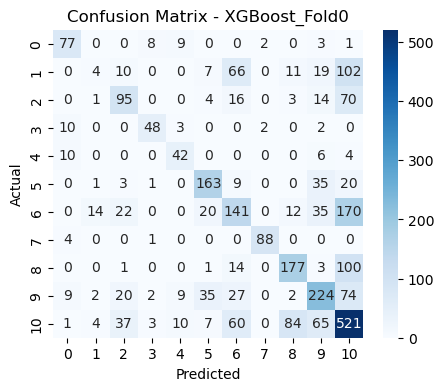

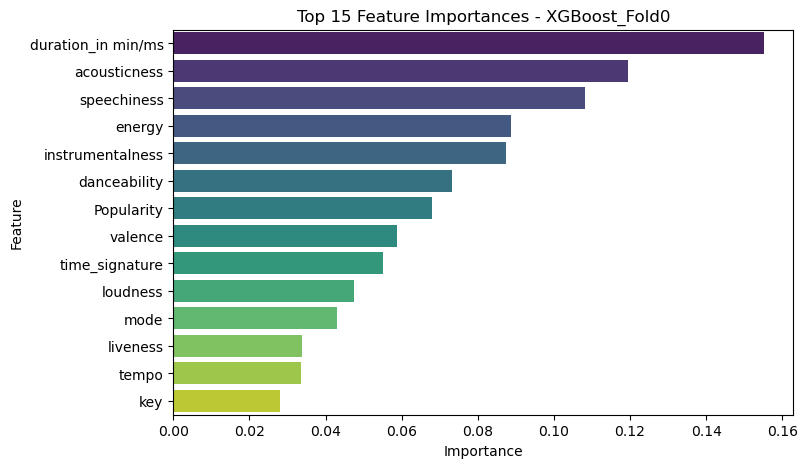

2025/11/21 11:18:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\XGBoost_Fold0_classification_best_111249_20251121_111817_model.pkl


2025/11/21 11:18:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[I 2025-11-21 11:18:24,246] A new study created in memory with name: no-name-588ddede-878f-4202-8047-d1d0dccb0df1


✅ Dữ liệu đã lưu local: experiments/data/processed\XGBoost_Fold0_classification_best_111249_20251121_111824_data.csv
  -> XGBoost Fold 0 F1 Macro: 0.5786

Training CatBoost...

🚀 Start run: CatBoost_Fold0_classification_best_111824
🔍 Phát hiện 0 cột phân loại từ X_train: []
🔍 Đang tìm tham số tốt nhất cho CatBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[W 2025-11-21 11:18:24,254] Trial 0 failed with parameters: {'depth': 8, 'learning_rate': 0.020123576004696355, 'iterations': 809, 'l2_leaf_reg': 0.18461882970153407, 'subsample': 0.8867429313124302, 'colsample_bylevel': 0.5575417829375338} because of the following error: TypeError("catboost.core.CatBoostClassifier() got multiple values for keyword argument 'eval_metric'").
Traceback (most recent call last):
  File "C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "d:\SGU\CNTT\ML\Team_SGU_25_ML_Fundamental\Challenge\3_MusicGenreClassification\src\model\Catboost.py", line 105, in <lambda>
    study.optimize(lambda trial: self._objective_optuna(trial, X_train, y_train),
                                 ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\SGU\CNTT\ML\Team_SGU_25_ML_Fundamental\Challenge\3_MusicGenreClassification\src\model\Catboost.py", line 57, in _objective_op

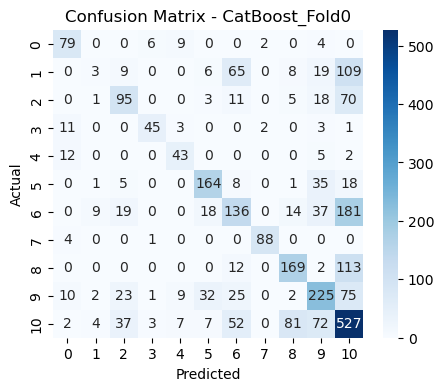

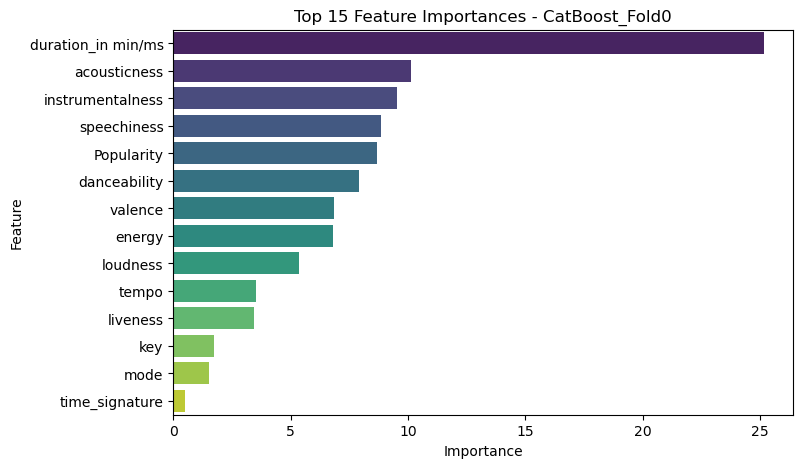

2025/11/21 11:18:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\CatBoost_Fold0_classification_best_111824_20251121_111838_model.pkl


2025/11/21 11:18:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[I 2025-11-21 11:18:43,944] A new study created in memory with name: no-name-8b643aa5-7fdf-419b-b715-c69e480d321b


✅ Dữ liệu đã lưu local: experiments/data/processed\CatBoost_Fold0_classification_best_111824_20251121_111843_data.csv
  -> CatBoost Fold 0 F1 Macro: 0.5777

========== Fold 1 ==========

Training RandomForest...

🚀 Start run: RandomForest_Fold1_classification_best_111843
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 11:18:45,904] Trial 0 finished with value: 0.5580498690510217 and parameters: {'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_samples': 0.9464683128080251}. Best is trial 0 with value: 0.5580498690510217.
[I 2025-11-21 11:18:49,178] Trial 1 finished with value: 0.5563801815138372 and parameters: {'n_estimators': 300, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 0.7, 'max_samples': 0.8394597829163332}. Best is trial 0 with value: 0.5580498690510217.
[I 2025-11-21 11:18:54,767] Trial 2 finished with value: 0.5543610730231823 and parameters: {'n_estimators': 500, 'max_depth': 17, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_samples': 0.855754067243907}. Best is trial 0 with value: 0.5580498690510217.
[I 2025-11-21 11:18:56,272] Trial 3 finished with value: 0.4758695494605421 and parameters: {'n_estimators': 500, 'max_depth': 6, 'min_samples_split'

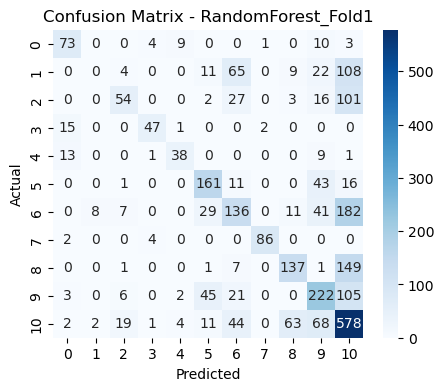

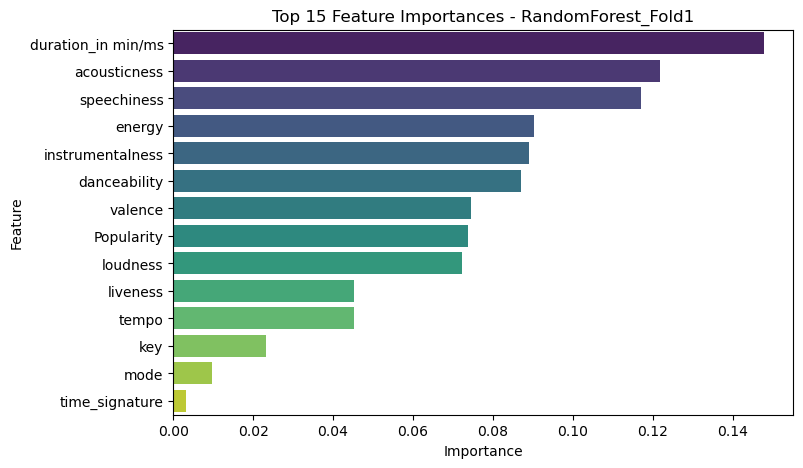

2025/11/21 11:19:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Model đã được lưu tại: experiments/models\RandomForest_Fold1_best.pkl
✅ Mô hình đã lưu local: experiments/models\RandomForest_Fold1_classification_best_111843_20251121_111926_model.pkl


2025/11/21 11:19:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\RandomForest_Fold1_classification_best_111843_20251121_111932_data.csv
  -> RandomForest Fold 1 F1 Macro: 0.5546


[I 2025-11-21 11:19:32,508] A new study created in memory with name: no-name-58168a90-039a-408d-aace-f153f41f8256



Training LightGBM...

🚀 Start run: LightGBM_Fold1_classification_best_111932
🔍 Đang tìm tham số tốt nhất cho LightGBM bằng Optuna (10 lần thử)...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-11-21 11:19:45,138] Trial 0 finished with value: 0.5504759181919928 and parameters: {'n_estimators': 1000, 'learning_rate': 0.06363714823771878, 'max_depth': 4, 'num_leaves': 177, 'subsample': 0.5115168864155831, 'colsample_bytree': 0.8223833051826381, 'lambda_l1': 0.00014774052777210102, 'lambda_l2': 0.0007627891169485982, 'min_child_samples': 20}. Best is trial 0 with value: 0.5504759181919928.
[I 2025-11-21 11:19:53,409] Trial 1 finished with value: 0.5672954017824902 and parameters: {'n_estimators': 921, 'learning_rate': 0.010794700006417256, 'max_depth': 3, 'num_leaves': 170, 'subsample': 0.8936642572947294, 'colsample_bytree': 0.8257684785068444, 'lambda_l1': 2.2081091491766214e-05, 'lambda_l2': 3.373308281516492e-07, 'min_child_samples': 42}. Best is trial 1 with value: 0.5672954017824902.
[I 2025-11-21 11:20:09,716] Trial 2 finished with value: 0.5508639136649834 and parameters: {'n_estimators': 559, 'learning_rate': 0.13687792739814678, 'max_depth': 9, 'num_leaves': 37

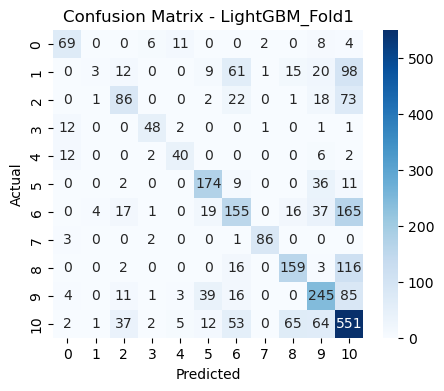

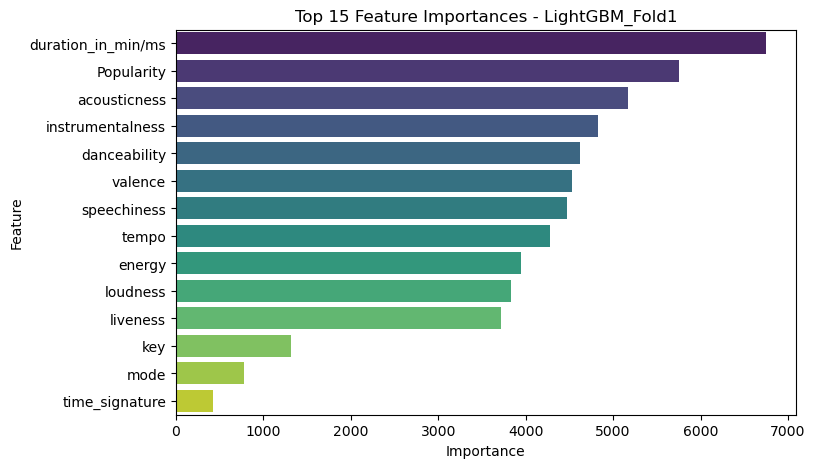

✅ Đã chạy đánh giá đầy đủ cho task: classification.


2025/11/21 11:23:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\LightGBM_Fold1_classification_best_111932_20251121_112335_model.pkl


2025/11/21 11:23:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\LightGBM_Fold1_classification_best_111932_20251121_112343_data.csv
[LightGBM] [Warning] lambda_l1 is set=2.404313485877887, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.404313485877887
[LightGBM] [Warning] lambda_l2 is set=1.0049705704038736e-07, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0049705704038736e-07
  -> LightGBM Fold 1 F1 Macro: 0.5813
[LightGBM] [Warning] lambda_l1 is set=2.404313485877887, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.404313485877887
[LightGBM] [Warning] lambda_l2 is set=1.0049705704038736e-07, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0049705704038736e-07


[I 2025-11-21 11:23:43,944] A new study created in memory with name: no-name-c8e75172-c79a-4fb3-9980-ef12f22f3114



Training XGBoost...

🚀 Start run: XGBoost_Fold1_classification_best_112343
🔍 Đang tìm tham số tốt nhất cho XGBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 11:24:01,225] Trial 0 finished with value: 0.5639065730302059 and parameters: {'n_estimators': 1213, 'learning_rate': 0.010382015745290855, 'max_depth': 7, 'subsample': 0.5207139789530884, 'colsample_bytree': 0.5150318343867213, 'reg_alpha': 6.370653994089558e-08, 'reg_lambda': 1.7495128321812445, 'min_child_weight': 7, 'gamma': 0.009481275761870037}. Best is trial 0 with value: 0.5639065730302059.
[I 2025-11-21 11:24:13,534] Trial 1 finished with value: 0.5640377347770098 and parameters: {'n_estimators': 724, 'learning_rate': 0.011741091687238444, 'max_depth': 8, 'subsample': 0.9156416172057631, 'colsample_bytree': 0.8174728871777723, 'reg_alpha': 0.07721109081666398, 'reg_lambda': 1.2138305453129703, 'min_child_weight': 10, 'gamma': 0.01020020476379151}. Best is trial 1 with value: 0.5640377347770098.
[I 2025-11-21 11:24:23,258] Trial 2 finished with value: 0.5681587702737922 and parameters: {'n_estimators': 672, 'learning_rate': 0.010288224759454217, 'max_depth': 6, 's

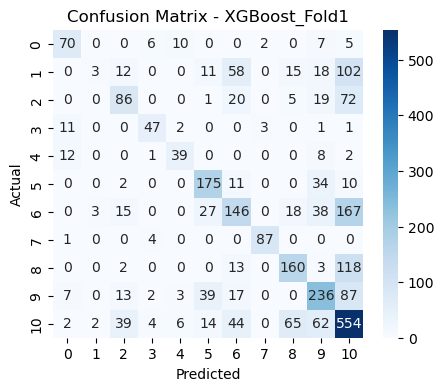

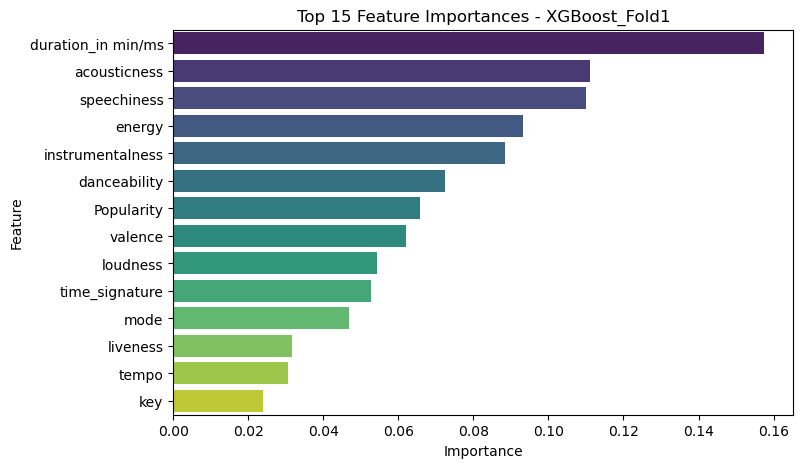

2025/11/21 11:28:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\XGBoost_Fold1_classification_best_112343_20251121_112834_model.pkl


2025/11/21 11:28:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[I 2025-11-21 11:28:39,716] A new study created in memory with name: no-name-1b41632b-000b-4cd7-8dc4-22b328439b65


✅ Dữ liệu đã lưu local: experiments/data/processed\XGBoost_Fold1_classification_best_112343_20251121_112839_data.csv
  -> XGBoost Fold 1 F1 Macro: 0.5744

Training CatBoost...

🚀 Start run: CatBoost_Fold1_classification_best_112839
🔍 Phát hiện 0 cột phân loại từ X_train: []
🔍 Đang tìm tham số tốt nhất cho CatBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[W 2025-11-21 11:28:39,725] Trial 0 failed with parameters: {'depth': 6, 'learning_rate': 0.04207670117351551, 'iterations': 1985, 'l2_leaf_reg': 0.39857362760416987, 'subsample': 0.6041930392571613, 'colsample_bylevel': 0.8494843446385927} because of the following error: TypeError("catboost.core.CatBoostClassifier() got multiple values for keyword argument 'eval_metric'").
Traceback (most recent call last):
  File "C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "d:\SGU\CNTT\ML\Team_SGU_25_ML_Fundamental\Challenge\3_MusicGenreClassification\src\model\Catboost.py", line 105, in <lambda>
    study.optimize(lambda trial: self._objective_optuna(trial, X_train, y_train),
                                 ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\SGU\CNTT\ML\Team_SGU_25_ML_Fundamental\Challenge\3_MusicGenreClassification\src\model\Catboost.py", line 57, in _objective_op

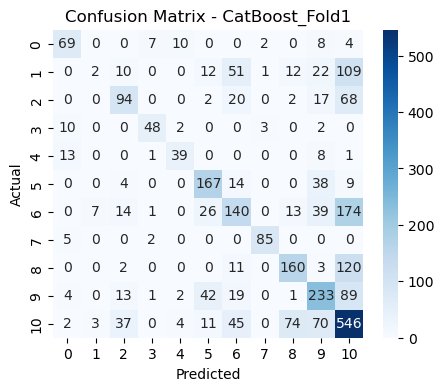

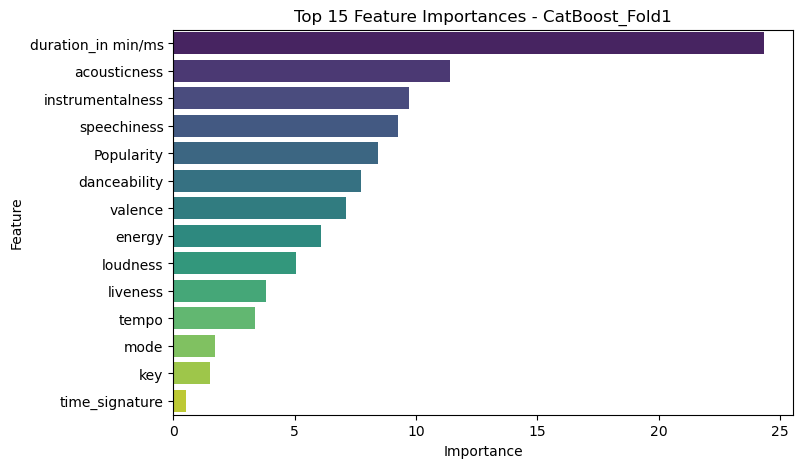

2025/11/21 11:28:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\CatBoost_Fold1_classification_best_112839_20251121_112854_model.pkl


2025/11/21 11:28:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[I 2025-11-21 11:28:59,910] A new study created in memory with name: no-name-51357500-42a4-4dec-9fc0-00cc0e4279fd


✅ Dữ liệu đã lưu local: experiments/data/processed\CatBoost_Fold1_classification_best_112839_20251121_112859_data.csv
  -> CatBoost Fold 1 F1 Macro: 0.5742

========== Fold 2 ==========

Training RandomForest...

🚀 Start run: RandomForest_Fold2_classification_best_112859
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 11:29:04,641] Trial 0 finished with value: 0.5589693618050191 and parameters: {'n_estimators': 500, 'max_depth': 18, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_samples': 0.8801981890577961}. Best is trial 0 with value: 0.5589693618050191.
[I 2025-11-21 11:29:09,300] Trial 1 finished with value: 0.5579737142241002 and parameters: {'n_estimators': 500, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 0.5, 'max_samples': 0.9447977000697564}. Best is trial 0 with value: 0.5589693618050191.
[I 2025-11-21 11:29:11,690] Trial 2 finished with value: 0.5617749895769901 and parameters: {'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_samples': 0.8633333424095744}. Best is trial 2 with value: 0.5617749895769901.
[I 2025-11-21 11:29:12,429] Trial 3 finished with value: 0.48102754496865363 and parameters: {'n_estimators': 100, 'max_depth': 5, 'min_samples_spli

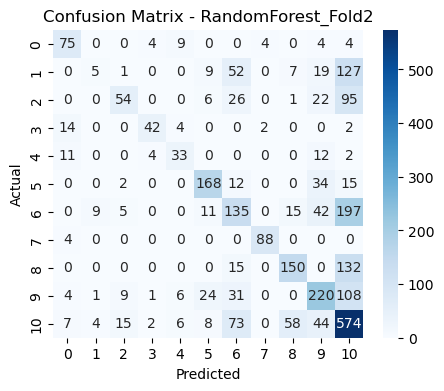

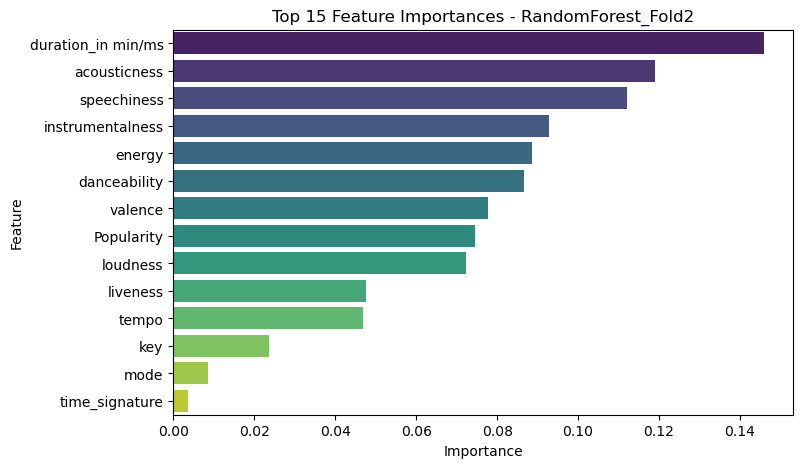

2025/11/21 11:29:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


💾 Model đã được lưu tại: experiments/models\RandomForest_Fold2_best.pkl
✅ Mô hình đã lưu local: experiments/models\RandomForest_Fold2_classification_best_112859_20251121_112936_model.pkl


2025/11/21 11:29:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\RandomForest_Fold2_classification_best_112859_20251121_112941_data.csv
  -> RandomForest Fold 2 F1 Macro: 0.5542


[I 2025-11-21 11:29:42,011] A new study created in memory with name: no-name-cc415990-542b-4a8d-b0f4-08b879a083e8



Training LightGBM...

🚀 Start run: LightGBM_Fold2_classification_best_112941
🔍 Đang tìm tham số tốt nhất cho LightGBM bằng Optuna (10 lần thử)...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-11-21 11:30:24,178] Trial 0 finished with value: 0.5567253038602721 and parameters: {'n_estimators': 1194, 'learning_rate': 0.012754647425776122, 'max_depth': 10, 'num_leaves': 200, 'subsample': 0.9942560297928614, 'colsample_bytree': 0.8006285626353689, 'lambda_l1': 0.00033737631497496496, 'lambda_l2': 0.0009636845702769146, 'min_child_samples': 75}. Best is trial 0 with value: 0.5567253038602721.
[I 2025-11-21 11:31:32,811] Trial 1 finished with value: 0.5513567419608933 and parameters: {'n_estimators': 1619, 'learning_rate': 0.02748441662165669, 'max_depth': 12, 'num_leaves': 51, 'subsample': 0.6573344857124439, 'colsample_bytree': 0.8766073718025202, 'lambda_l1': 0.00016693538166781142, 'lambda_l2': 6.185488307642158e-08, 'min_child_samples': 45}. Best is trial 0 with value: 0.5567253038602721.
[I 2025-11-21 11:32:17,376] Trial 2 finished with value: 0.5476979028550294 and parameters: {'n_estimators': 1913, 'learning_rate': 0.089643167415596, 'max_depth': 6, 'num_leaves': 1

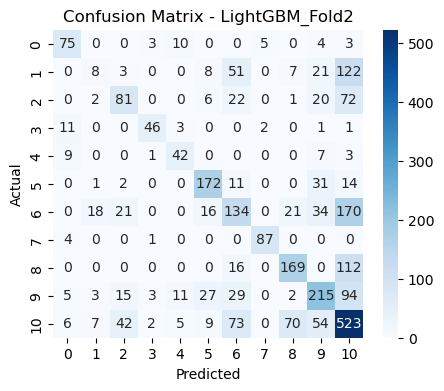

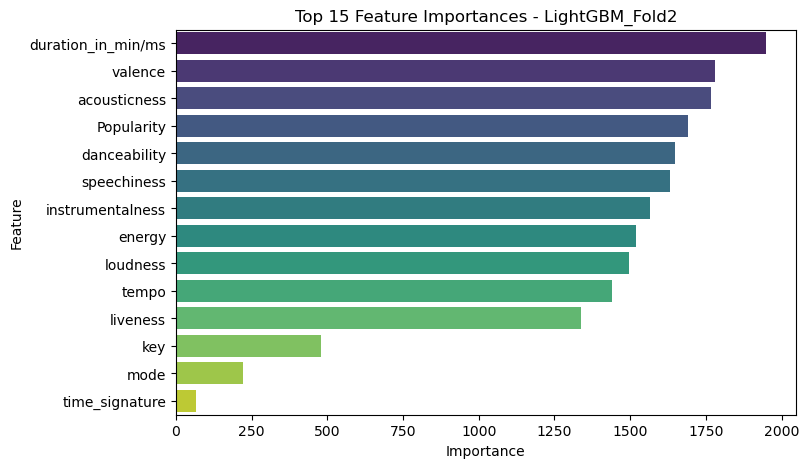

2025/11/21 11:37:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Đã chạy đánh giá đầy đủ cho task: classification.
✅ Mô hình đã lưu local: experiments/models\LightGBM_Fold2_classification_best_112941_20251121_113746_model.pkl


2025/11/21 11:37:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[I 2025-11-21 11:37:53,217] A new study created in memory with name: no-name-d99ab1ed-9e6a-48b9-9d0e-b3f75d6c6b9a


✅ Dữ liệu đã lưu local: experiments/data/processed\LightGBM_Fold2_classification_best_112941_20251121_113753_data.csv
[LightGBM] [Warning] lambda_l1 is set=0.0009299363192895992, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0009299363192895992
[LightGBM] [Warning] lambda_l2 is set=9.331804566503439e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.331804566503439e-05
  -> LightGBM Fold 2 F1 Macro: 0.5754
[LightGBM] [Warning] lambda_l1 is set=0.0009299363192895992, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0009299363192895992
[LightGBM] [Warning] lambda_l2 is set=9.331804566503439e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=9.331804566503439e-05

Training XGBoost...

🚀 Start run: XGBoost_Fold2_classification_best_113753
🔍 Đang tìm tham số tốt nhất cho XGBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 11:38:25,519] Trial 0 finished with value: 0.5623040258076198 and parameters: {'n_estimators': 1724, 'learning_rate': 0.025952873088259505, 'max_depth': 12, 'subsample': 0.6476322621114778, 'colsample_bytree': 0.5358966286379571, 'reg_alpha': 0.009468110773909853, 'reg_lambda': 1.5848932050135923e-08, 'min_child_weight': 4, 'gamma': 1.7574948739164698e-07}. Best is trial 0 with value: 0.5623040258076198.
[I 2025-11-21 11:38:45,561] Trial 1 finished with value: 0.5501707940976254 and parameters: {'n_estimators': 1333, 'learning_rate': 0.12223828898994363, 'max_depth': 9, 'subsample': 0.819867983075276, 'colsample_bytree': 0.6249064561258626, 'reg_alpha': 0.00012706209595817616, 'reg_lambda': 0.0037853561376902365, 'min_child_weight': 3, 'gamma': 2.6685853891335537e-08}. Best is trial 0 with value: 0.5623040258076198.
[I 2025-11-21 11:39:06,688] Trial 2 finished with value: 0.57356758041503 and parameters: {'n_estimators': 1846, 'learning_rate': 0.013901212752259941, 'max_d

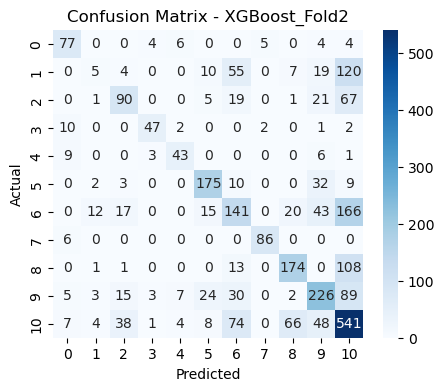

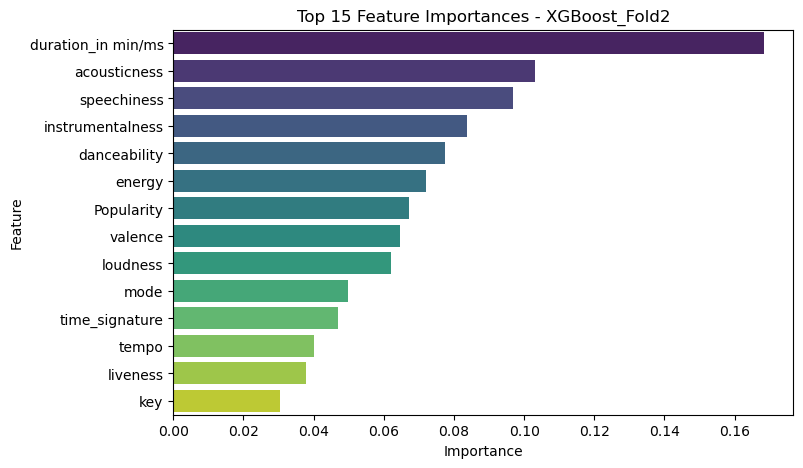

2025/11/21 11:46:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\XGBoost_Fold2_classification_best_113753_20251121_114607_model.pkl


2025/11/21 11:46:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\XGBoost_Fold2_classification_best_113753_20251121_114622_data.csv
  -> XGBoost Fold 2 F1 Macro: 0.5913

Training CatBoost...

🚀 Start run: CatBoost_Fold2_classification_best_114622


[I 2025-11-21 11:46:22,938] A new study created in memory with name: no-name-20b2a1c1-f8b2-47f8-8407-76c0521417ba


🔍 Phát hiện 0 cột phân loại từ X_train: []
🔍 Đang tìm tham số tốt nhất cho CatBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[W 2025-11-21 11:46:22,954] Trial 0 failed with parameters: {'depth': 6, 'learning_rate': 0.010498592187702471, 'iterations': 658, 'l2_leaf_reg': 4.96863659671992e-06, 'subsample': 0.5151052846126423, 'colsample_bylevel': 0.5172370160281918} because of the following error: TypeError("catboost.core.CatBoostClassifier() got multiple values for keyword argument 'eval_metric'").
Traceback (most recent call last):
  File "C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "d:\SGU\CNTT\ML\Team_SGU_25_ML_Fundamental\Challenge\3_MusicGenreClassification\src\model\Catboost.py", line 105, in <lambda>
    study.optimize(lambda trial: self._objective_optuna(trial, X_train, y_train),
                                 ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\SGU\CNTT\ML\Team_SGU_25_ML_Fundamental\Challenge\3_MusicGenreClassification\src\model\Catboost.py", line 57, in _objective_o

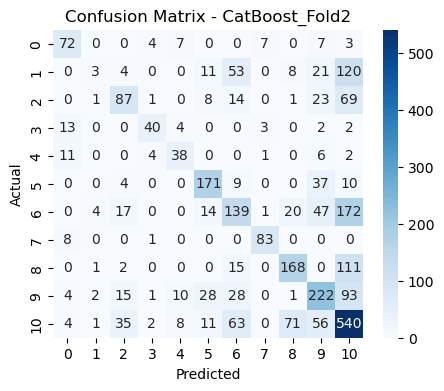

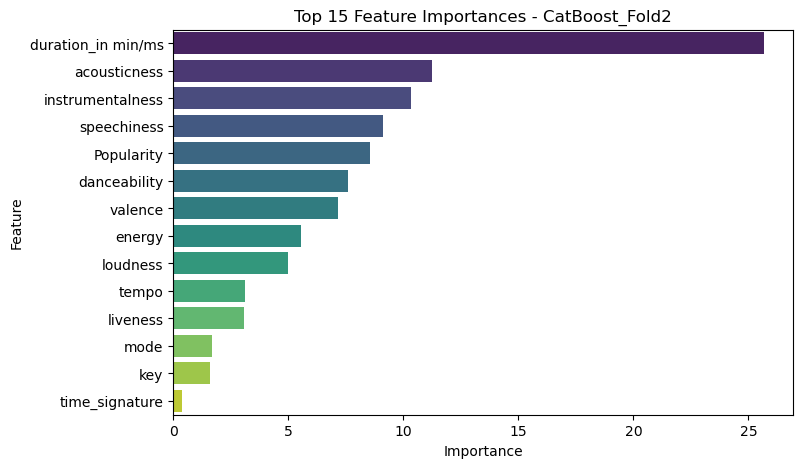

2025/11/21 11:46:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\CatBoost_Fold2_classification_best_114622_20251121_114653_model.pkl


2025/11/21 11:47:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[I 2025-11-21 11:47:05,289] A new study created in memory with name: no-name-abde2940-4bde-451a-8f69-4a0f82ab4373


✅ Dữ liệu đã lưu local: experiments/data/processed\CatBoost_Fold2_classification_best_114622_20251121_114705_data.csv
  -> CatBoost Fold 2 F1 Macro: 0.5577

========== Fold 3 ==========

Training RandomForest...

🚀 Start run: RandomForest_Fold3_classification_best_114705
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 11:47:15,961] Trial 0 finished with value: 0.5513541975095673 and parameters: {'n_estimators': 300, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_samples': 0.8654555245526092}. Best is trial 0 with value: 0.5513541975095673.
[I 2025-11-21 11:47:17,283] Trial 1 finished with value: 0.5213019845346402 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_samples': 0.9225028628933982}. Best is trial 0 with value: 0.5513541975095673.
[I 2025-11-21 11:47:19,710] Trial 2 finished with value: 0.4741116473880942 and parameters: {'n_estimators': 300, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_samples': 0.831239429544753}. Best is trial 0 with value: 0.5513541975095673.
[I 2025-11-21 11:47:26,628] Trial 3 finished with value: 0.554067243130003 and parameters: {'n_estimators': 300, 'max_depth': 18, 'min_samples_split

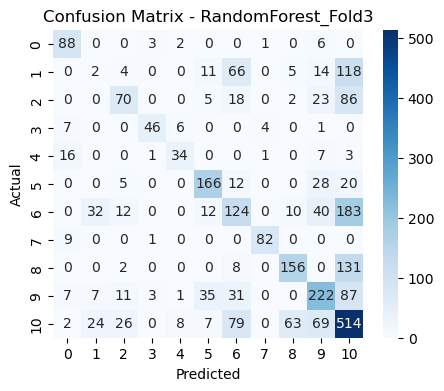

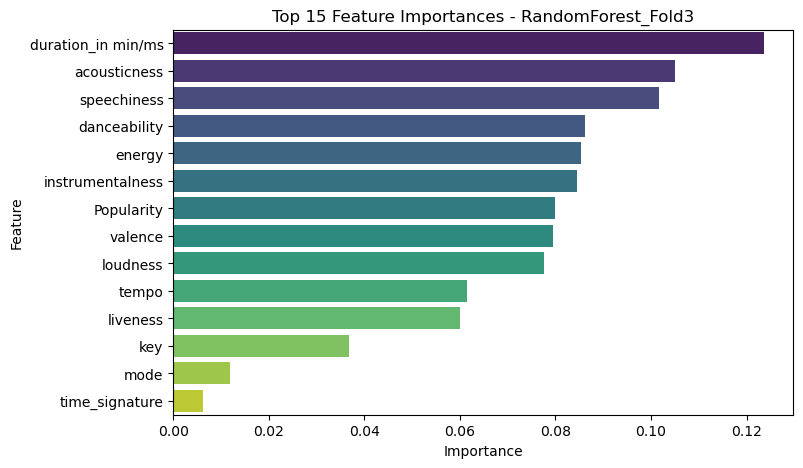

💾 Model đã được lưu tại: experiments/models\RandomForest_Fold3_best.pkl


2025/11/21 11:49:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\RandomForest_Fold3_classification_best_114705_20251121_114908_model.pkl


2025/11/21 11:49:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\RandomForest_Fold3_classification_best_114705_20251121_114923_data.csv
  -> RandomForest Fold 3 F1 Macro: 0.5634


[I 2025-11-21 11:49:24,532] A new study created in memory with name: no-name-fa454cc9-97c3-4a6c-be1b-ee4a8aba2665



Training LightGBM...

🚀 Start run: LightGBM_Fold3_classification_best_114924
🔍 Đang tìm tham số tốt nhất cho LightGBM bằng Optuna (10 lần thử)...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-11-21 11:51:18,960] Trial 0 finished with value: 0.54459639624734 and parameters: {'n_estimators': 819, 'learning_rate': 0.19855623344481174, 'max_depth': 12, 'num_leaves': 70, 'subsample': 0.6367508580888424, 'colsample_bytree': 0.502866552810519, 'lambda_l1': 6.160568727540615e-05, 'lambda_l2': 0.005656389426323609, 'min_child_samples': 21}. Best is trial 0 with value: 0.54459639624734.
[I 2025-11-21 11:52:14,341] Trial 1 finished with value: 0.5492775118295492 and parameters: {'n_estimators': 1732, 'learning_rate': 0.045715436610124074, 'max_depth': 4, 'num_leaves': 109, 'subsample': 0.5378983029692699, 'colsample_bytree': 0.7781732321073214, 'lambda_l1': 1.1585481671113447e-06, 'lambda_l2': 0.7778594475913589, 'min_child_samples': 66}. Best is trial 1 with value: 0.5492775118295492.
[I 2025-11-21 11:52:28,784] Trial 2 finished with value: 0.5662283632695196 and parameters: {'n_estimators': 610, 'learning_rate': 0.013491016299985453, 'max_depth': 8, 'num_leaves': 163, 'subsa

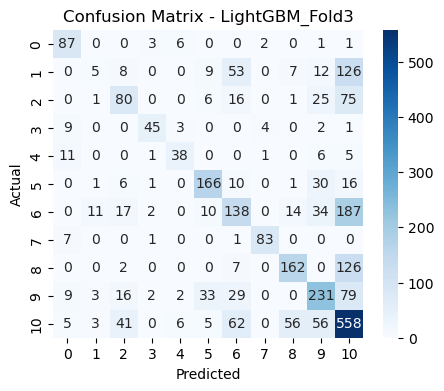

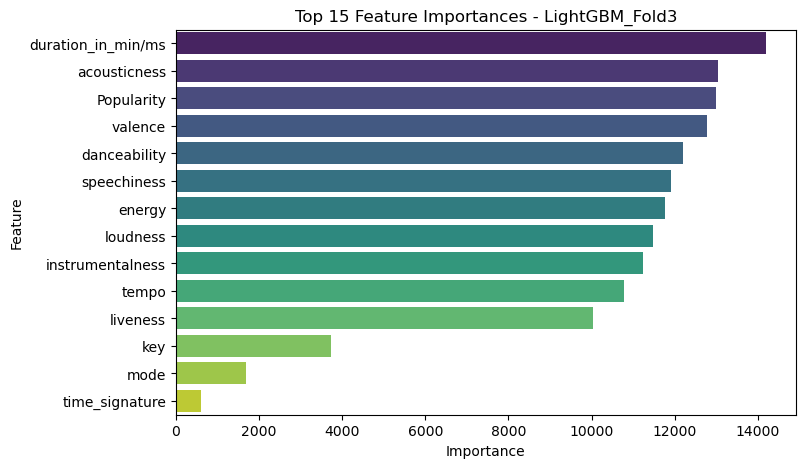

✅ Đã chạy đánh giá đầy đủ cho task: classification.


2025/11/21 12:05:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\LightGBM_Fold3_classification_best_114924_20251121_120547_model.pkl


2025/11/21 12:06:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\LightGBM_Fold3_classification_best_114924_20251121_120603_data.csv
[LightGBM] [Warning] lambda_l1 is set=0.24003316923584522, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.24003316923584522
[LightGBM] [Warning] lambda_l2 is set=0.0023964286951450495, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0023964286951450495
  -> LightGBM Fold 3 F1 Macro: 0.5815
[LightGBM] [Warning] lambda_l1 is set=0.24003316923584522, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.24003316923584522
[LightGBM] [Warning] lambda_l2 is set=0.0023964286951450495, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0023964286951450495


[I 2025-11-21 12:06:04,712] A new study created in memory with name: no-name-559d62d8-a5d9-4e0b-962e-b3b347551454



Training XGBoost...

🚀 Start run: XGBoost_Fold3_classification_best_120604
🔍 Đang tìm tham số tốt nhất cho XGBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 12:06:24,619] Trial 0 finished with value: 0.5576688032154992 and parameters: {'n_estimators': 745, 'learning_rate': 0.06221587063924342, 'max_depth': 5, 'subsample': 0.7901179217904094, 'colsample_bytree': 0.7850954068390029, 'reg_alpha': 2.2819113863951603, 'reg_lambda': 3.5993701502434404e-06, 'min_child_weight': 10, 'gamma': 1.1212565281494375e-08}. Best is trial 0 with value: 0.5576688032154992.
[I 2025-11-21 12:07:11,854] Trial 1 finished with value: 0.5565849822917729 and parameters: {'n_estimators': 1653, 'learning_rate': 0.018591788012804745, 'max_depth': 7, 'subsample': 0.9157178290479197, 'colsample_bytree': 0.6645935631232547, 'reg_alpha': 1.4064013423297748, 'reg_lambda': 0.1825598705072605, 'min_child_weight': 10, 'gamma': 4.073555238364896e-06}. Best is trial 0 with value: 0.5576688032154992.
[I 2025-11-21 12:07:34,730] Trial 2 finished with value: 0.5601572112723966 and parameters: {'n_estimators': 1151, 'learning_rate': 0.03631187478430512, 'max_depth': 4

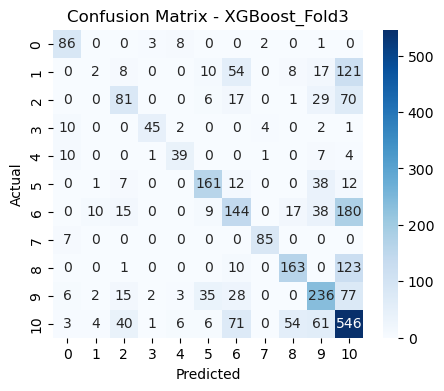

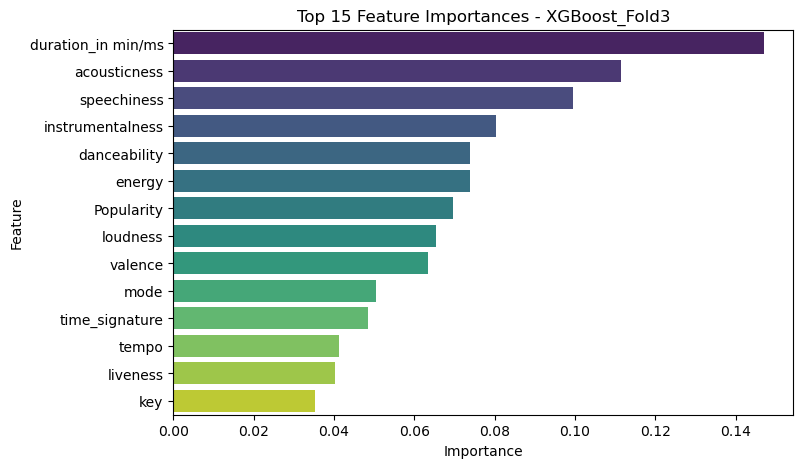

2025/11/21 12:16:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\XGBoost_Fold3_classification_best_120604_20251121_121627_model.pkl


2025/11/21 12:16:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\XGBoost_Fold3_classification_best_120604_20251121_121633_data.csv
  -> XGBoost Fold 3 F1 Macro: 0.5821

Training CatBoost...

🚀 Start run: CatBoost_Fold3_classification_best_121634


[I 2025-11-21 12:16:34,192] A new study created in memory with name: no-name-e1a5bc72-940c-4466-894b-3600cf9d7cf7


🔍 Phát hiện 0 cột phân loại từ X_train: []
🔍 Đang tìm tham số tốt nhất cho CatBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[W 2025-11-21 12:16:34,202] Trial 0 failed with parameters: {'depth': 6, 'learning_rate': 0.022108906050205653, 'iterations': 1784, 'l2_leaf_reg': 1.5069868515912764e-06, 'subsample': 0.7949133160283048, 'colsample_bylevel': 0.8310854387162427} because of the following error: TypeError("catboost.core.CatBoostClassifier() got multiple values for keyword argument 'eval_metric'").
Traceback (most recent call last):
  File "C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "d:\SGU\CNTT\ML\Team_SGU_25_ML_Fundamental\Challenge\3_MusicGenreClassification\src\model\Catboost.py", line 105, in <lambda>
    study.optimize(lambda trial: self._objective_optuna(trial, X_train, y_train),
                                 ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\SGU\CNTT\ML\Team_SGU_25_ML_Fundamental\Challenge\3_MusicGenreClassification\src\model\Catboost.py", line 57, in _objectiv

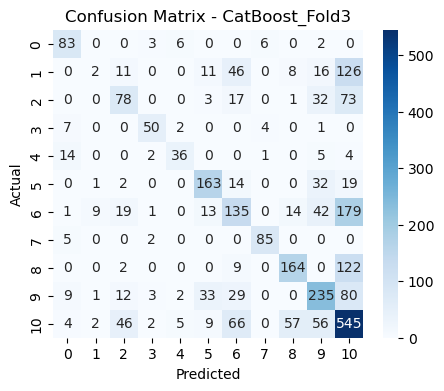

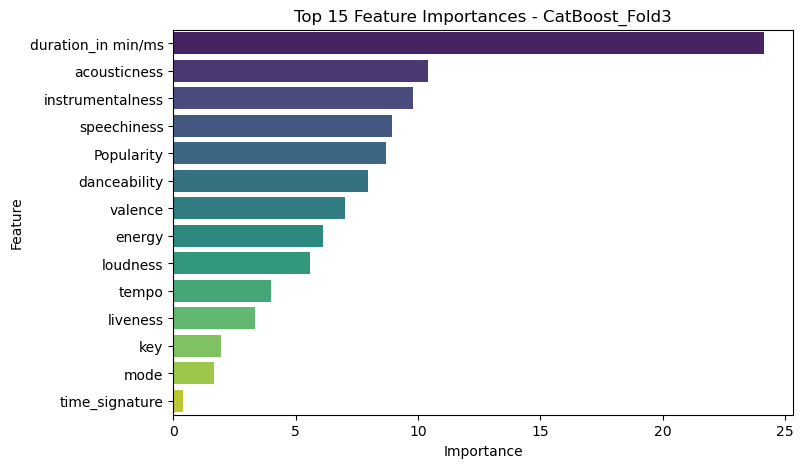

2025/11/21 12:16:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\CatBoost_Fold3_classification_best_121634_20251121_121652_model.pkl


2025/11/21 12:16:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
[I 2025-11-21 12:16:57,396] A new study created in memory with name: no-name-7cfe9757-6349-45dd-adc3-89c1b24649ef


✅ Dữ liệu đã lưu local: experiments/data/processed\CatBoost_Fold3_classification_best_121634_20251121_121657_data.csv
  -> CatBoost Fold 3 F1 Macro: 0.5745

========== Fold 4 ==========

Training RandomForest...

🚀 Start run: RandomForest_Fold4_classification_best_121657
🔍 Đang tìm tham số tốt nhất cho Random Forest bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 12:16:58,670] Trial 0 finished with value: 0.5560611855072418 and parameters: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 0.7, 'max_samples': 0.8184125223814251}. Best is trial 0 with value: 0.5560611855072418.
[I 2025-11-21 12:16:59,362] Trial 1 finished with value: 0.5383977347278657 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_samples': 0.7449316500097098}. Best is trial 0 with value: 0.5560611855072418.
[I 2025-11-21 12:17:01,293] Trial 2 finished with value: 0.559613682885718 and parameters: {'n_estimators': 200, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_samples': 0.86369864036376}. Best is trial 2 with value: 0.559613682885718.
[I 2025-11-21 12:17:05,739] Trial 3 finished with value: 0.5639070576967855 and parameters: {'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 

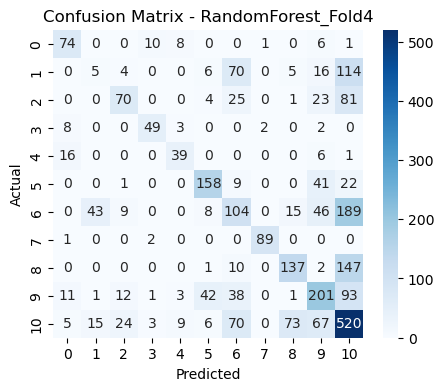

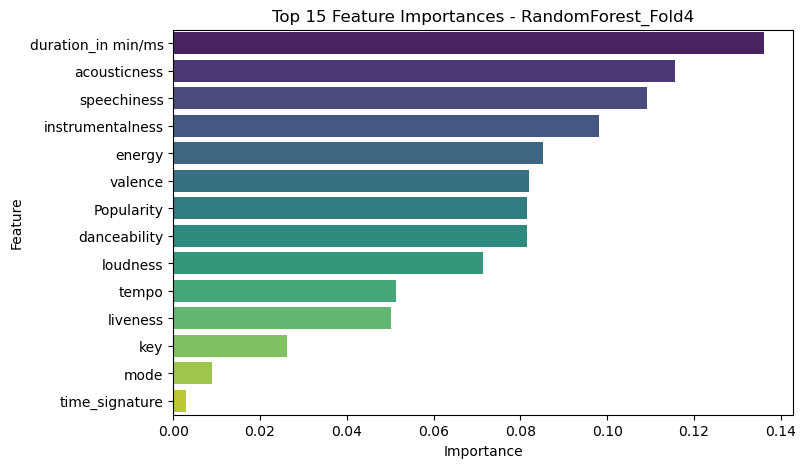

💾 Model đã được lưu tại: experiments/models\RandomForest_Fold4_best.pkl


2025/11/21 12:17:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\RandomForest_Fold4_classification_best_121657_20251121_121755_model.pkl


2025/11/21 12:18:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\RandomForest_Fold4_classification_best_121657_20251121_121801_data.csv
  -> RandomForest Fold 4 F1 Macro: 0.5481

Training LightGBM...

🚀 Start run: LightGBM_Fold4_classification_best_121802


[I 2025-11-21 12:18:02,283] A new study created in memory with name: no-name-61ba2af3-08b0-4183-9e64-855f60ac468a


🔍 Đang tìm tham số tốt nhất cho LightGBM bằng Optuna (10 lần thử)...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2025-11-21 12:19:08,202] Trial 0 finished with value: 0.5525851488693675 and parameters: {'n_estimators': 1916, 'learning_rate': 0.1444142977558649, 'max_depth': 12, 'num_leaves': 119, 'subsample': 0.5031918056059843, 'colsample_bytree': 0.66750115990796, 'lambda_l1': 0.0003411666200390607, 'lambda_l2': 0.01735415949956334, 'min_child_samples': 35}. Best is trial 0 with value: 0.5525851488693675.
[I 2025-11-21 12:19:31,150] Trial 1 finished with value: 0.5451292876187651 and parameters: {'n_estimators': 1737, 'learning_rate': 0.09140938038654423, 'max_depth': 4, 'num_leaves': 126, 'subsample': 0.6482450206573983, 'colsample_bytree': 0.6344750030967107, 'lambda_l1': 3.756201381687765e-05, 'lambda_l2': 0.0038141484283672287, 'min_child_samples': 64}. Best is trial 0 with value: 0.5525851488693675.
[I 2025-11-21 12:19:50,815] Trial 2 finished with value: 0.5515224773248097 and parameters: {'n_estimators': 1656, 'learning_rate': 0.051330931237185046, 'max_depth': 3, 'num_leaves': 154, '

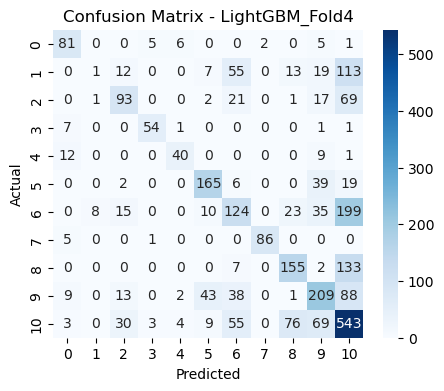

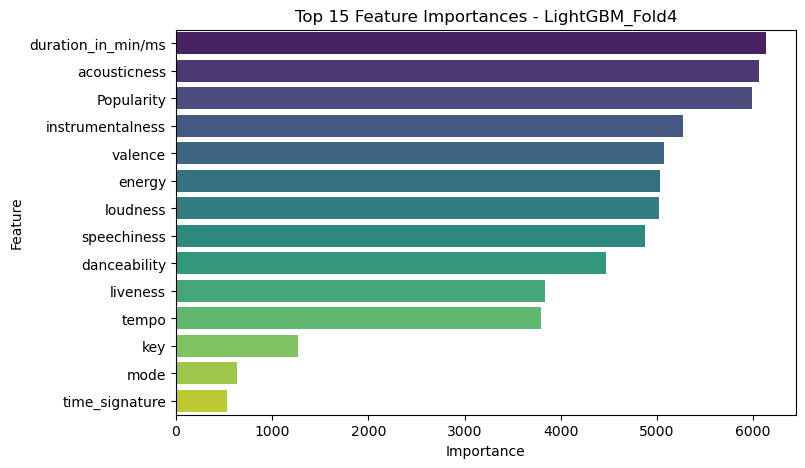

✅ Đã chạy đánh giá đầy đủ cho task: classification.


2025/11/21 12:25:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\LightGBM_Fold4_classification_best_121802_20251121_122503_model.pkl


2025/11/21 12:25:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\LightGBM_Fold4_classification_best_121802_20251121_122510_data.csv
[LightGBM] [Warning] lambda_l1 is set=6.779206367963962e-06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.779206367963962e-06
[LightGBM] [Warning] lambda_l2 is set=7.363563722370585e-08, reg_lambda=0.0 will be ignored. Current value: lambda_l2=7.363563722370585e-08
  -> LightGBM Fold 4 F1 Macro: 0.5847
[LightGBM] [Warning] lambda_l1 is set=6.779206367963962e-06, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.779206367963962e-06
[LightGBM] [Warning] lambda_l2 is set=7.363563722370585e-08, reg_lambda=0.0 will be ignored. Current value: lambda_l2=7.363563722370585e-08

Training XGBoost...

🚀 Start run: XGBoost_Fold4_classification_best_122510


[I 2025-11-21 12:25:11,024] A new study created in memory with name: no-name-b743d099-17ae-4a7a-a8aa-d5912b91bfbc


🔍 Đang tìm tham số tốt nhất cho XGBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-21 12:25:39,605] Trial 0 finished with value: 0.5563826038596292 and parameters: {'n_estimators': 1952, 'learning_rate': 0.024838977810230152, 'max_depth': 7, 'subsample': 0.8134758282438818, 'colsample_bytree': 0.5476743159193758, 'reg_alpha': 5.79261003064088e-08, 'reg_lambda': 0.010958894137479405, 'min_child_weight': 3, 'gamma': 1.0870575798568222e-08}. Best is trial 0 with value: 0.5563826038596292.
[I 2025-11-21 12:25:51,099] Trial 1 finished with value: 0.5653205272580525 and parameters: {'n_estimators': 1294, 'learning_rate': 0.04771748563778756, 'max_depth': 3, 'subsample': 0.9683863380899149, 'colsample_bytree': 0.7680603072128396, 'reg_alpha': 0.0729178458464885, 'reg_lambda': 1.0293391612759908, 'min_child_weight': 5, 'gamma': 5.271618026587977e-08}. Best is trial 1 with value: 0.5653205272580525.
[I 2025-11-21 12:26:11,871] Trial 2 finished with value: 0.5538803108960656 and parameters: {'n_estimators': 1663, 'learning_rate': 0.04546796362898979, 'max_depth': 6,

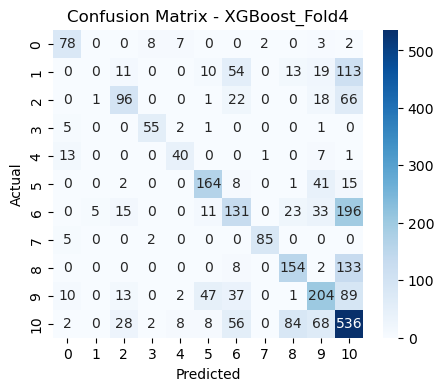

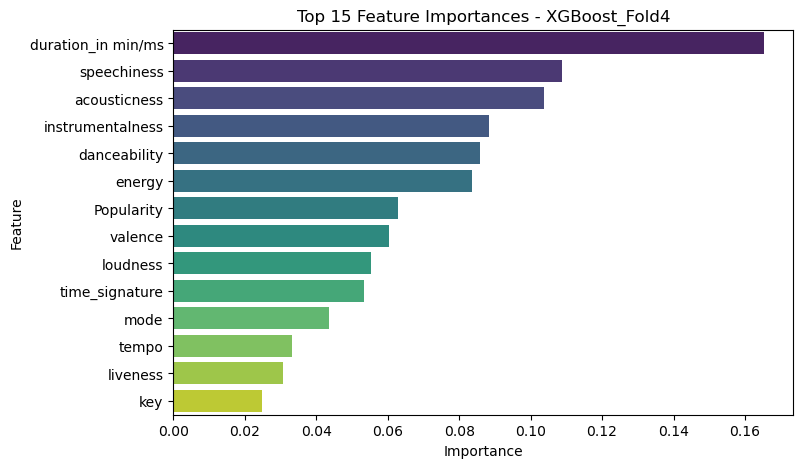

2025/11/21 12:35:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\XGBoost_Fold4_classification_best_122510_20251121_123506_model.pkl


2025/11/21 12:35:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\XGBoost_Fold4_classification_best_122510_20251121_123522_data.csv
  -> XGBoost Fold 4 F1 Macro: 0.5773


[I 2025-11-21 12:35:22,770] A new study created in memory with name: no-name-20516db4-1c5a-4a19-a1d5-fae0e684ba49



Training CatBoost...

🚀 Start run: CatBoost_Fold4_classification_best_123522
🔍 Phát hiện 0 cột phân loại từ X_train: []
🔍 Đang tìm tham số tốt nhất cho CatBoost bằng Optuna (20 lần thử)...


  0%|          | 0/20 [00:00<?, ?it/s]

[W 2025-11-21 12:35:22,784] Trial 0 failed with parameters: {'depth': 6, 'learning_rate': 0.012495434811361046, 'iterations': 1607, 'l2_leaf_reg': 1.177287742694981, 'subsample': 0.9675175986720043, 'colsample_bylevel': 0.9051552914674832} because of the following error: TypeError("catboost.core.CatBoostClassifier() got multiple values for keyword argument 'eval_metric'").
Traceback (most recent call last):
  File "C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "d:\SGU\CNTT\ML\Team_SGU_25_ML_Fundamental\Challenge\3_MusicGenreClassification\src\model\Catboost.py", line 105, in <lambda>
    study.optimize(lambda trial: self._objective_optuna(trial, X_train, y_train),
                                 ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\SGU\CNTT\ML\Team_SGU_25_ML_Fundamental\Challenge\3_MusicGenreClassification\src\model\Catboost.py", line 57, in _objective_opt

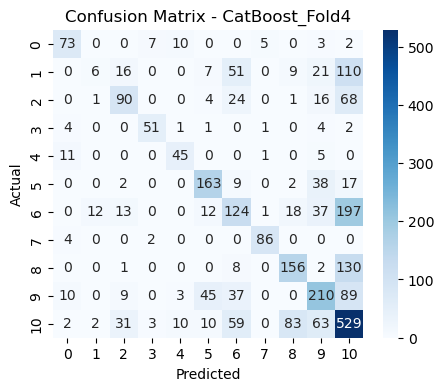

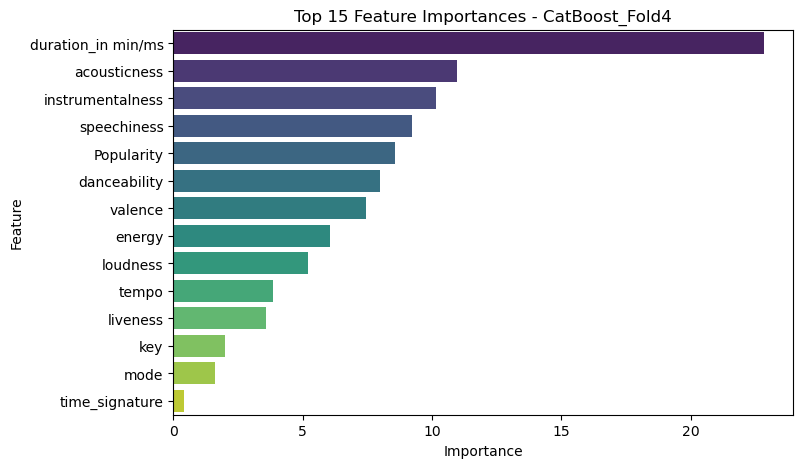

2025/11/21 12:35:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Mô hình đã lưu local: experiments/models\CatBoost_Fold4_classification_best_123522_20251121_123555_model.pkl


2025/11/21 12:36:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Dữ liệu đã lưu local: experiments/data/processed\CatBoost_Fold4_classification_best_123522_20251121_123607_data.csv
  -> CatBoost Fold 4 F1 Macro: 0.5749

CV Complete.


In [4]:
# Initialize storage
model_pipelines = {
    "RandomForest": RFPipeline(experiment_name="Music_V2"),
    "LightGBM": LightGBMPipeline(experiment_name="Music_V2"),
    "XGBoost": XGBoostPipeline(experiment_name="Music_V2"),
    "CatBoost": CatBoostPipeline(experiment_name="Music_V2")
}

oof_preds = {name: np.zeros((len(y), len(le.classes_))) for name in model_pipelines}
test_preds = {name: np.zeros((len(X_test), len(le.classes_))) for name in model_pipelines}
cv_scores = {name: [] for name in model_pipelines}

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"Starting {N_SPLITS}-Fold CV for {list(model_pipelines.keys())}...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_encoded)):
    print(f"\n========== Fold {fold} ==========")
    X_tr, X_val = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
    y_tr, y_val = y_encoded[train_idx], y_encoded[val_idx]
    
    for name, pipeline in model_pipelines.items():
        print(f"\nTraining {name}...")
        
        # Run pipeline (trains model and logs to tracking)
        # Note: We pass pre-split data to avoid re-splitting inside the model
        model = pipeline.run(
            df=None, # Not used when X_train is provided
            target_col=target_col, 
            task="classification", 
            model_name=f"{name}_Fold{fold}",
            X_train=X_tr, y_train=y_tr, X_test=X_val, y_test=y_val
        )
        
        # Predict Probabilities on Validation
        val_probs = model.predict_proba(X_val)
        oof_preds[name][val_idx] = val_probs
        
        # Evaluate
        val_pred_labels = np.argmax(val_probs, axis=1)
        f1 = f1_score(y_val, val_pred_labels, average="macro")
        cv_scores[name].append(f1)
        print(f"  -> {name} Fold {fold} F1 Macro: {f1:.4f}")
        
        # Predict Probabilities on Test (accumulate for averaging)
        test_probs = model.predict_proba(X_test_scaled)
        test_preds[name] += test_probs / N_SPLITS
        
        # Save model manually if needed (pipeline already saves best, but we want per-fold)
        # pipeline.run saves the model, so we are good.

print("\nCV Complete.")

## 5. Model Comparison

In [5]:
results = []
for name in model_pipelines:
    mean_f1 = np.mean(cv_scores[name])
    std_f1 = np.std(cv_scores[name])
    
    # Calculate OOF Score
    oof_labels = np.argmax(oof_preds[name], axis=1)
    oof_f1 = f1_score(y_encoded, oof_labels, average="macro")
    
    results.append({
        "Model": name,
        "Mean CV F1": mean_f1,
        "Std CV F1": std_f1,
        "OOF F1": oof_f1
    })

results_df = pd.DataFrame(results).sort_values(by="OOF F1", ascending=False)
display(results_df)

# Save metrics
results_df.to_csv(os.path.join(EXP_DIR, "model_comparison.csv"), index=False)

,Model,Mean CV F1,Std CV F1,OOF F1
2,XGBoost,0.580747,0.005830,0.580819
1,LightGBM,0.580455,0.003037,0.580571
3,CatBoost,0.571812,0.007168,0.571978
0,RandomForest,0.556624,0.005795,0.556995


## 6. Ensemble & Submission
We use a weighted average of the probabilities from the best models.

In [6]:
# Define weights based on OOF performance (Simple heuristic: give more weight to better models)
# For simplicity, we can use equal weights or manually tuned weights.
# Here we use a simple weighted average based on OOF F1 score.

weights = {}
total_score = results_df["OOF F1"].sum()
for _, row in results_df.iterrows():
    weights[row["Model"]] = row["OOF F1"] / total_score

print("Ensemble Weights:", weights)

# Compute Ensemble Probabilities
ensemble_probs = np.zeros_like(test_preds[list(model_pipelines.keys())[0]])

for name in model_pipelines:
    ensemble_probs += test_preds[name] * weights[name]

# Convert to Labels
final_pred_indices = np.argmax(ensemble_probs, axis=1)
final_pred_labels = le.inverse_transform(final_pred_indices)

# Create Submission
submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
submission["Class"] = final_pred_labels

sub_path = os.path.join(EXP_DIR, "submission_music_v2_ensemble.csv")
submission.to_csv(sub_path, index=False)

print(f"Saved ensemble submission to: {sub_path}")
display(submission.head())

Ensemble Weights: {'XGBoost': np.float64(0.25359271689252555), 'LightGBM': np.float64(0.2534842666441096), 'CatBoost': np.float64(0.2497323462052765), 'RandomForest': np.float64(0.24319067025808816)}
Saved ensemble submission to: experiments/Music_V2\submission_music_v2_ensemble.csv


,Id,Class
0,14397,6
1,14398,6
2,14399,9
3,14400,10
4,14401,5


In [7]:
# Save OOF predictions and Ensemble probs for future stacking
with open(os.path.join(EXP_DIR, "oof_preds_all.pkl"), "wb") as f:
    pickle.dump(oof_preds, f)

with open(os.path.join(EXP_DIR, "test_preds_all.pkl"), "wb") as f:
    pickle.dump(test_preds, f)

print("Artifacts saved.")

Artifacts saved.
